# last

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import math
from urllib.parse import urlparse

print("📥 1. Loading and Cleaning Dataset...")
df = pd.read_csv('C:/Users/user/Desktop/react/phishing_site_urls.csv')

# Convert labels to 1 (Phishing) and 0 (Safe)
df['Label'] = df['Label'].map({'bad': 1, 'good': 0})

# Sanity Checks
total_rows = len(df)
null_values = df.isnull().sum().sum()
duplicates = df.duplicated(subset=['URL']).sum()

print(f"Total Rows: {total_rows}")
print(f"Missing Values: {null_values}")
print(f"Duplicate URLs found: {duplicates}")

# Drop duplicates to prevent the model from memorizing repeated data
if duplicates > 0:
    df = df.drop_duplicates(subset=['URL'])
    print(f"✅ Dropped duplicates. New row count: {len(df)}")

C:\Users\user\anaconda3\lib\site-packages\pandas\core\computation\expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.8.3' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
C:\Users\user\anaconda3\lib\site-packages\pandas\core\arrays\masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (
C:\Users\user\anaconda3\lib\site-packages\scipy\__init__.py:155: UserWarning: A NumPy version >=1.18.5 and <1.25.0 is required for this version of SciPy (detected version 1.26.4
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


📥 1. Loading and Cleaning Dataset...
Total Rows: 549346
Missing Values: 0
Duplicate URLs found: 42151
✅ Dropped duplicates. New row count: 507195



📊 2. Visualizing Class Balance...


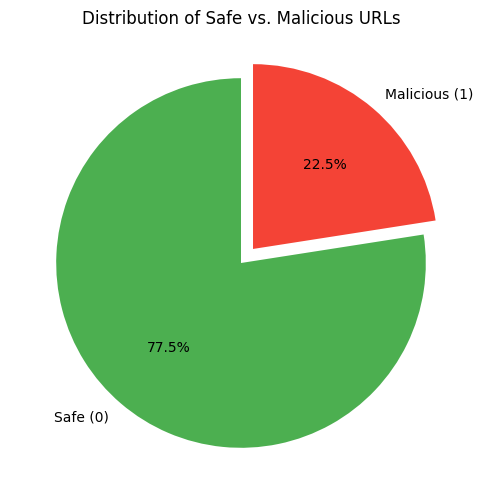

In [2]:
print("\n📊 2. Visualizing Class Balance...")

plt.figure(figsize=(6, 6))
class_counts = df['Label'].value_counts()
plt.pie(class_counts, labels=['Safe (0)', 'Malicious (1)'], autopct='%1.1f%%', 
        colors=['#4CAF50', '#F44336'], startangle=90, explode=(0, 0.1))
plt.title('Distribution of Safe vs. Malicious URLs')
plt.show()

# If the minority class is less than ~15-20%, we would need to balance it. 
# (Spoiler: This Kaggle dataset is roughly 70/30, which is perfectly fine for Random Forest!)

In [3]:
print("\n⚙️ 3. Initializing Advanced Feature Extraction...")

# def calculate_entropy(text):
#     """Calculates Shannon Entropy to detect randomly generated strings."""
#     if not text: return 0
#     entropy = 0
#     for x in set(text):
#         p_x = float(text.count(x)) / len(text)
#         entropy += - p_x * math.log(p_x, 2)
#     return entropy

# def get_advanced_url_features(url):
#     url = str(url).lower()
#     if not url.startswith('http'):
#         url_to_parse = 'http://' + url
#     else:
#         url_to_parse = url
        
#     parsed = urlparse(url_to_parse)
#     hostname = parsed.hostname if parsed.hostname else ""
#     path = parsed.path if parsed.path else ""
    
#     # Expanded suspicious keywords
#     sus_words = ['login', 'verify', 'update', 'secure', 'account', 'banking', 
#                  'paypal', 'cmd', 'webscr', 'admin', 'free', 'bonus', 'claim',
#                  'support', 'service', 'recover', 'wallet']
    
#     # 1. Length Features
#     url_len = len(url)
#     host_len = len(hostname)
#     path_len = len(path)
    
#     # 2. Character Counts
#     num_dots = url.count('.')
#     num_hyphens = url.count('-')
#     num_underscores = url.count('_')
#     num_slashes = url.count('/')
#     num_question_marks = url.count('?')
#     num_equals = url.count('=')
#     num_at = url.count('@')
#     num_ampersands = url.count('&')
    
#     # 3. Alphanumeric Properties
#     num_digits = sum(c.isdigit() for c in url)
#     num_letters = sum(c.isalpha() for c in url)
    
#     # 4. Ratios & Math (Very strong indicators)
#     digit_letter_ratio = num_digits / num_letters if num_letters > 0 else 0
#     url_entropy = calculate_entropy(url)
    
#     # 5. Logical/Keyword Features
#     num_sus_words = sum(1 for word in sus_words if word in url)
#     has_ip_address = 1 if re.search(r'\b\d{1,3}\.\d{1,3}\.\d{1,3}\.\d{1,3}\b', hostname) else 0
#     has_https = 1 if url.startswith('https://') else 0
#     has_shortener = 1 if any(short in hostname for short in ['bit.ly', 'goo.gl', 't.co', 'tinyurl']) else 0
#     directory_depth = path.count('/')
    
#     return {
#         'url_length': url_len, 'hostname_length': host_len, 'path_length': path_len,
#         'num_dots': num_dots, 'num_hyphens': num_hyphens, 'num_underscores': num_underscores,
#         'num_slashes': num_slashes, 'num_question_marks': num_question_marks, 'num_equals': num_equals,
#         'num_at': num_at, 'num_ampersands': num_ampersands, 'num_digits': num_digits,
#         'num_letters': num_letters, 'digit_letter_ratio': digit_letter_ratio, 
#         'url_entropy': url_entropy, 'num_sus_words': num_sus_words, 
#         'has_ip_address': has_ip_address, 'has_https': has_https, 
#         'has_shortener': has_shortener, 'directory_depth': directory_depth
#     }




def calculate_entropy(text):
    """Calculates Shannon Entropy to detect randomly generated strings."""
    if not text: return 0
    entropy = 0
    import math
    for x in set(text):
        p_x = float(text.count(x)) / len(text)
        entropy += - p_x * math.log(p_x, 2)
    return entropy

def get_advanced_url_features(url):
    url = str(url).lower()
    if not url.startswith('http'):
        url_to_parse = 'http://' + url
    else:
        url_to_parse = url
        
    # --- 🛡️ THE BULLETPROOF FIX ---
    try:
        parsed = urlparse(url_to_parse)
        hostname = parsed.hostname if parsed.hostname else ""
        path = parsed.path if parsed.path else ""
    except ValueError:
        # If urlparse crashes due to "Invalid IPv6 URL", strip brackets and retry
        url_to_parse_clean = url_to_parse.replace('[', '').replace(']', '')
        try:
            parsed = urlparse(url_to_parse_clean)
            hostname = parsed.hostname if parsed.hostname else ""
            path = parsed.path if parsed.path else ""
        except ValueError:
            # Ultimate fallback if the string is completely broken
            hostname = ""
            path = url
    # ------------------------------
    
    # Expanded suspicious keywords
    sus_words = ['login', 'verify', 'update', 'secure', 'account', 'banking', 
                 'paypal', 'cmd', 'webscr', 'admin', 'free', 'bonus', 'claim',
                 'support', 'service', 'recover', 'wallet']
    
    # 1. Length Features
    url_len = len(url)
    host_len = len(hostname)
    path_len = len(path)
    
    # 2. Character Counts
    num_dots = url.count('.')
    num_hyphens = url.count('-')
    num_underscores = url.count('_')
    num_slashes = url.count('/')
    num_question_marks = url.count('?')
    num_equals = url.count('=')
    num_at = url.count('@')
    num_ampersands = url.count('&')
    
    # 3. Alphanumeric Properties
    num_digits = sum(c.isdigit() for c in url)
    num_letters = sum(c.isalpha() for c in url)
    
    # 4. Ratios & Math
    digit_letter_ratio = num_digits / num_letters if num_letters > 0 else 0
    url_entropy = calculate_entropy(url)
    
    import re
    # 5. Logical/Keyword Features
    num_sus_words = sum(1 for word in sus_words if word in url)
    has_ip_address = 1 if re.search(r'\b\d{1,3}\.\d{1,3}\.\d{1,3}\.\d{1,3}\b', hostname) else 0
    has_https = 1 if url.startswith('https://') else 0
    has_shortener = 1 if any(short in hostname for short in ['bit.ly', 'goo.gl', 't.co', 'tinyurl']) else 0
    directory_depth = path.count('/')
    
    return {
        'url_length': url_len, 'hostname_length': host_len, 'path_length': path_len,
        'num_dots': num_dots, 'num_hyphens': num_hyphens, 'num_underscores': num_underscores,
        'num_slashes': num_slashes, 'num_question_marks': num_question_marks, 'num_equals': num_equals,
        'num_at': num_at, 'num_ampersands': num_ampersands, 'num_digits': num_digits,
        'num_letters': num_letters, 'digit_letter_ratio': digit_letter_ratio, 
        'url_entropy': url_entropy, 'num_sus_words': num_sus_words, 
        'has_ip_address': has_ip_address, 'has_https': has_https, 
        'has_shortener': has_shortener, 'directory_depth': directory_depth
    }


⚙️ 3. Initializing Advanced Feature Extraction...



🔍 4. Visualizing Feature Impact (Sample)...


C:\Users\user\anaconda3\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\user\anaconda3\lib\site-packages\seaborn\_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
C:\Users\user\anaconda3\lib\site-packages\seaborn\_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
C:\Users\user\anaconda3\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is depr

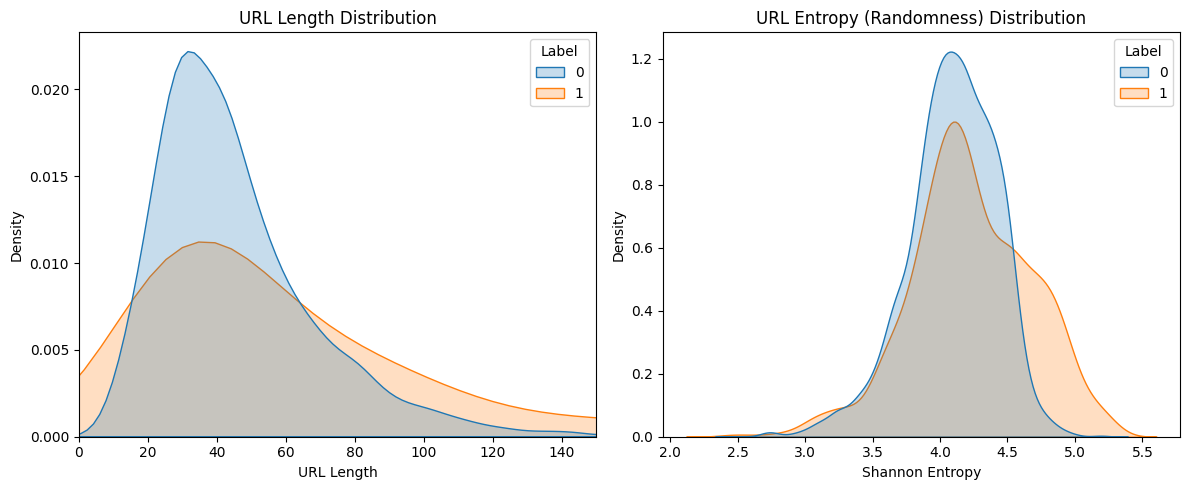

In [4]:
print("\n🔍 4. Visualizing Feature Impact (Sample)...")

# Take a random sample of 5,000 rows to visualize quickly without waiting 20 minutes
sample_df = df.sample(5000, random_state=42).copy()

# Extract features just for the sample
sample_features = pd.DataFrame(sample_df['URL'].apply(get_advanced_url_features).tolist())
sample_features['Label'] = sample_df['Label'].values

# Plot 1: URL Length Comparison
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.kdeplot(data=sample_features, x='url_length', hue='Label', fill=True, common_norm=False)
plt.xlim(0, 150) # zooming in on normal lengths
plt.title('URL Length Distribution')
plt.xlabel('URL Length')

# Plot 2: Entropy Comparison
plt.subplot(1, 2, 2)
sns.kdeplot(data=sample_features, x='url_entropy', hue='Label', fill=True, common_norm=False)
plt.title('URL Entropy (Randomness) Distribution')
plt.xlabel('Shannon Entropy')

plt.tight_layout()
plt.show()

⚙️ 1. Extracting features for all 507,000+ URLs (This will take a few minutes)...

✂️ 2. Splitting data into 80% Train and 20% Test...
🧠 3. Training the Random Forest Model...

📊 4. Evaluating Model...
✅ Final Model Accuracy: 91.63%

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.98      0.95     78705
           1       0.90      0.70      0.79     22734

    accuracy                           0.92    101439
   macro avg       0.91      0.84      0.87    101439
weighted avg       0.92      0.92      0.91    101439



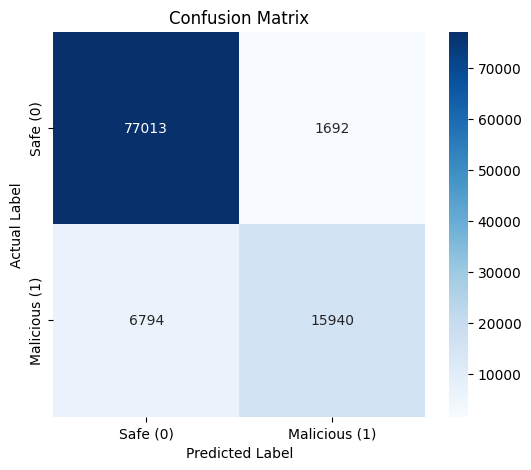


🏆 5. Calculating Feature Importance...


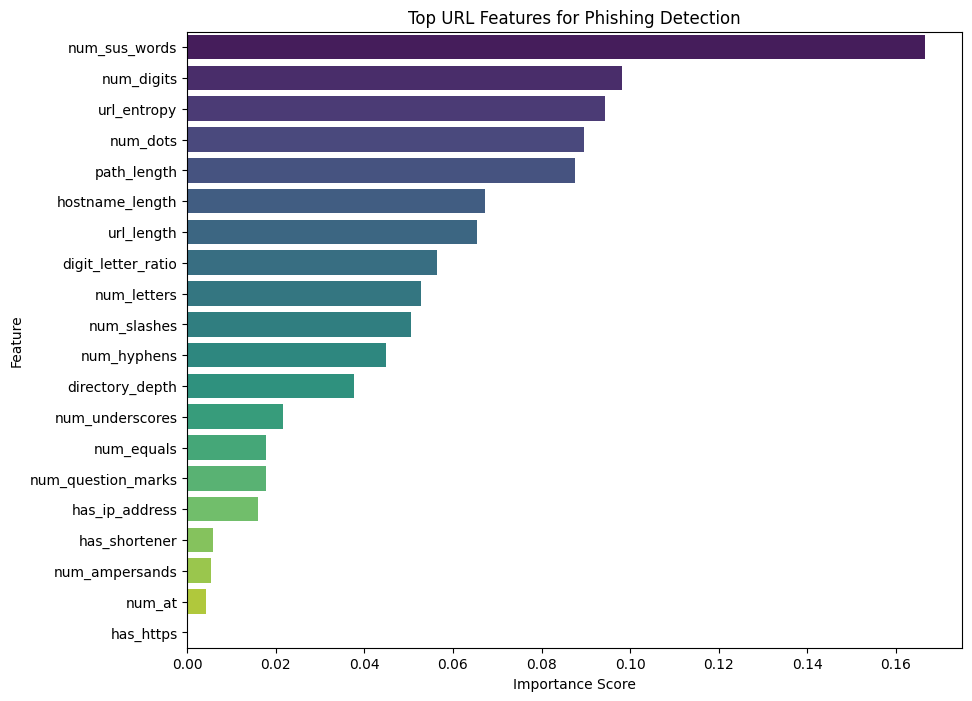

💾 Model successfully saved as 'qr_guard_rf_model.pkl'

🕵️‍♂️ 6. Investigating Real-World Test Cases...

Target URL: https://www.apple.com/iphone/
Verdict:    🟢 SAFE
Confidence: 64.01%
Key Traits: Length=29, Entropy=3.80, Sus Words=0, IP Address=False

Target URL: github.com/react-native-community
Verdict:    🟢 SAFE
Confidence: 99.82%
Key Traits: Length=33, Entropy=4.01, Sus Words=0, IP Address=False

Target URL: https://developer.mozilla.org/en-US/docs/Web/JavaScript
Verdict:    🔴 MALICIOUS
Confidence: 78.90%
Key Traits: Length=55, Entropy=4.38, Sus Words=0, IP Address=False

Target URL: http://192.168.1.45/login/secure-banking-update.php
Verdict:    🔴 MALICIOUS
Confidence: 98.00%
Key Traits: Length=51, Entropy=4.59, Sus Words=4, IP Address=True

Target URL: secure-verify-account.paypal.com.random-string-xyz.info/
Verdict:    🔴 MALICIOUS
Confidence: 98.00%
Key Traits: Length=56, Entropy=4.34, Sus Words=4, IP Address=False

Target URL: http://bit.ly/free-netflix-bonus-claim-now
Verdict:

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import joblib

# ==========================================
# 1. EXTRACT FEATURES FOR THE ENTIRE DATASET
# ==========================================
print("⚙️ 1. Extracting features for all 507,000+ URLs (This will take a few minutes)...")
# Assuming 'df' and 'get_advanced_url_features' are already loaded from your previous cell
X_features = pd.DataFrame(df['URL'].apply(get_advanced_url_features).tolist())
y_labels = df['Label']

# ==========================================
# 2. TRAIN/TEST SPLIT & MODEL TRAINING
# ==========================================
print("\n✂️ 2. Splitting data into 80% Train and 20% Test...")
X_train, X_test, y_train, y_test = train_test_split(X_features, y_labels, test_size=0.2, random_state=42)

print("🧠 3. Training the Random Forest Model...")
# n_jobs=-1 uses all CPU cores to train as fast as possible
rf_model = RandomForestClassifier(n_estimators=100, max_depth=25, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

# ==========================================
# 3. EVALUATION & CONFUSION MATRIX
# ==========================================
print("\n📊 4. Evaluating Model...")
y_pred = rf_model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(f"✅ Final Model Accuracy: {accuracy * 100:.2f}%")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Plot Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Safe (0)', 'Malicious (1)'], 
            yticklabels=['Safe (0)', 'Malicious (1)'])
plt.title('Confusion Matrix')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

# ==========================================
# 4. RANKING FEATURE IMPORTANCE
# ==========================================
print("\n🏆 5. Calculating Feature Importance...")
feature_importances = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': rf_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(data=feature_importances, x='Importance', y='Feature', palette='viridis')
plt.title('Top URL Features for Phishing Detection')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.show()

# Save the model!
joblib.dump(rf_model, 'qr_guard_rf_model.pkl')
print("💾 Model successfully saved as 'qr_guard_rf_model.pkl'")

# ==========================================
# 5. REAL-WORLD URL INVESTIGATOR
# ==========================================
print("\n🕵️‍♂️ 6. Investigating Real-World Test Cases...")

def investigate_url(url_string, model):
    """Extracts features from a raw string and predicts its safety."""
    # 1. Extract the exact same 24 features
    features_dict = get_advanced_url_features(url_string)
    
    # 2. Convert to DataFrame so it matches the model's expected format
    features_df = pd.DataFrame([features_dict])
    
    # 3. Predict
    prediction = model.predict(features_df)[0]
    probabilities = model.predict_proba(features_df)[0]
    
    # 4. Format Output
    status = "🔴 MALICIOUS" if prediction == 1 else "🟢 SAFE"
    confidence = probabilities[prediction] * 100
    
    print(f"\nTarget URL: {url_string}")
    print(f"Verdict:    {status}")
    print(f"Confidence: {confidence:.2f}%")
    print(f"Key Traits: Length={features_dict['url_length']}, "
          f"Entropy={features_dict['url_entropy']:.2f}, "
          f"Sus Words={features_dict['num_sus_words']}, "
          f"IP Address={bool(features_dict['has_ip_address'])}")

# Run the test cases!
test_cases = [
    # Normal / Safe
    "https://www.apple.com/iphone/",
    "github.com/react-native-community",
    "https://developer.mozilla.org/en-US/docs/Web/JavaScript",
    
    # Phishing / Suspicious
    "http://192.168.1.45/login/secure-banking-update.php",
    "secure-verify-account.paypal.com.random-string-xyz.info/",
    "http://bit.ly/free-netflix-bonus-claim-now",
    "http://nx-183-update.ru/cmd=login&verify=true"
]

for test_url in test_cases:
    investigate_url(test_url, rf_model)

In [6]:
demo_test_cases = [
    # --- 🟢 CLEARLY SAFE (Control Group) ---
    "https://www.helwan.edu.eg/",
    "https://reactnative.dev/docs/getting-started",
    "https://github.com/expo/expo",
    "https://www.google.com/maps",
    
    # --- 🔴 AGGRESSIVE PHISHING (IP Addresses & Sus Words) ---
    "http://192.168.1.55/secure-update/login.php?verify=true",
    "http://103.45.67.89/admin/webscr?cmd=_login-run",
    
    # --- 🔴 SNEAKY PHISHING (Dash-heavy & Suspicious Subdomains) ---
    "https://paypal-secure-account-verify.update-info.com/",
    "http://customer-support-service.banking-verify.ru/login/",
    "https://amazon-prime-bonus-reward.xyz/account-recovery/",
    
    # --- 🔴 GIBBERISH / SHORTENED (High Entropy) ---
    "http://bit.ly/free-netflix-movies-claim",
    "http://t.co/claim-your-bonus-now-8847xyz",
    "http://secure-login.apple.com.br.dj93jxj29dj.info/"
]

print("🚀 Running Demo Selection Batch...\n")
for test_url in demo_test_cases:
    investigate_url(test_url, rf_model)

🚀 Running Demo Selection Batch...


Target URL: https://www.helwan.edu.eg/
Verdict:    🟢 SAFE
Confidence: 72.37%
Key Traits: Length=26, Entropy=3.69, Sus Words=0, IP Address=False

Target URL: https://reactnative.dev/docs/getting-started
Verdict:    🟢 SAFE
Confidence: 63.43%
Key Traits: Length=44, Entropy=3.87, Sus Words=0, IP Address=False

Target URL: https://github.com/expo/expo
Verdict:    🟢 SAFE
Confidence: 57.01%
Key Traits: Length=28, Entropy=3.80, Sus Words=0, IP Address=False

Target URL: https://www.google.com/maps
Verdict:    🟢 SAFE
Confidence: 67.74%
Key Traits: Length=27, Entropy=3.78, Sus Words=0, IP Address=False

Target URL: http://192.168.1.55/secure-update/login.php?verify=true
Verdict:    🔴 MALICIOUS
Confidence: 98.00%
Key Traits: Length=55, Entropy=4.62, Sus Words=4, IP Address=True

Target URL: http://103.45.67.89/admin/webscr?cmd=_login-run
Verdict:    🔴 MALICIOUS
Confidence: 88.00%
Key Traits: Length=47, Entropy=4.93, Sus Words=4, IP Address=True

Target URL: htt

In [ ]:
# Save the model!
joblib.dump(rf_model, 'qr_guard_rf_model.pkl')
print("💾 Model successfully saved as 'qr_guard_rf_model.pkl'")

# ==========================================
# 5. REAL-WORLD URL INVESTIGATOR
# ==========================================
print("\n🕵️‍♂️ 6. Investigating Real-World Test Cases...")

def investigate_url(url_string, model):
    """Extracts features from a raw string and predicts its safety."""
    # 1. Extract the exact same 24 features
    features_dict = get_advanced_url_features(url_string)
    
    # 2. Convert to DataFrame so it matches the model's expected format
    features_df = pd.DataFrame([features_dict])
    
    # 3. Predict
    prediction = model.predict(features_df)[0]
    probabilities = model.predict_proba(features_df)[0]
    
    # 4. Format Output
    status = "🔴 MALICIOUS" if prediction == 1 else "🟢 SAFE"
    confidence = probabilities[prediction] * 100
    
    print(f"\nTarget URL: {url_string}")
    print(f"Verdict:    {status}")
    print(f"Confidence: {confidence:.2f}%")
    print(f"Key Traits: Length={features_dict['url_length']}, "
          f"Entropy={features_dict['url_entropy']:.2f}, "
          f"Sus Words={features_dict['num_sus_words']}, "
          f"IP Address={bool(features_dict['has_ip_address'])}")

# Run the test cases!
test_cases = [
    # Normal / Safe
    "https://www.apple.com/iphone/",
    "github.com/react-native-community",
    "https://developer.mozilla.org/en-US/docs/Web/JavaScript",
    
    # Phishing / Suspicious
    "http://192.168.1.45/login/secure-banking-update.php",
    "secure-verify-account.paypal.com.random-string-xyz.info/",
    "http://bit.ly/free-netflix-bonus-claim-now",
    "http://nx-183-update.ru/cmd=login&verify=true"
]

for test_url in test_cases:
    investigate_url(test_url, rf_model)